# 02 — Deep dive: "ARPDAU is falling. Fix it." (Part 2a)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from db import run_query, close
from style import BLUE, ORANGE, INK_2, MUTED, GREYS, SALE, save

pd.set_option("display.width", 140)

In [2]:
daily_tier = run_query("""
    WITH act AS (
        SELECT d.activity_dt AS dt, p.country_tier AS tier, COUNT(*) AS dau
        FROM player_day d JOIN player_profile p USING (device_id)
        GROUP BY d.activity_dt, p.country_tier
    ),
    rev AS (
        SELECT pc.event_dt AS dt, p.country_tier AS tier, SUM(pc.usd_amount) AS revenue
        FROM purchase_clean pc JOIN player_profile p USING (device_id)
        WHERE pc.usd_amount > 0
        GROUP BY pc.event_dt, p.country_tier
    )
    SELECT a.dt, a.tier, a.dau, COALESCE(r.revenue, 0) AS revenue
    FROM act a LEFT JOIN rev r USING (dt, tier)
    ORDER BY a.dt, a.tier
""")
daily_tier["dt"] = pd.to_datetime(daily_tier["dt"])
daily_tier["period"] = np.select(
    [daily_tier.dt <= "2026-01-30", daily_tier.dt >= "2026-04-01"], ["first_30", "last_30"], None)

# every gross dollar is captured (no revenue falls on a tier-day with zero DAU)
print("revenue in daily_tier:", round(daily_tier.revenue.sum(), 2),
      "| purchase_clean gross:", run_query("SELECT SUM(usd_amount) s FROM purchase_clean WHERE usd_amount > 0").s[0])

p = daily_tier.dropna(subset=["period"]).groupby("period")[["revenue", "dau"]].sum()
p["arpdau"] = p.revenue / p.dau
display(p)
change = p.loc["last_30", "arpdau"] - p.loc["first_30", "arpdau"]
print(f"ARPDAU {p.loc['first_30','arpdau']:.4f} -> {p.loc['last_30','arpdau']:.4f}  "
      f"change {change:+.4f} ({change / p.loc['first_30','arpdau']:+.1%})")
print(f"Revenue per day {p.loc['first_30','revenue']/30:,.0f} -> {p.loc['last_30','revenue']/30:,.0f} "
      f"({p.loc['last_30','revenue']/p.loc['first_30','revenue']:.2f}x)")

revenue in daily_tier: 217593.22 | purchase_clean gross: 217593.22


,revenue,dau,arpdau
period,,,
first_30,29188.90,82381,0.354316
last_30,83647.92,282781,0.295805


ARPDAU 0.3543 -> 0.2958  change -0.0585 (-16.5%)
Revenue per day 973 -> 2,788 (2.87x)


In [3]:
display(run_query("""
    SELECT CASE WHEN event_dt <= '2026-01-30' THEN 'first_30' ELSE 'last_30' END AS period,
           COUNT(DISTINCT event_dt) AS sale_days
    FROM purchase_clean
    WHERE sale_flag = 1 AND usd_amount > 0
      AND (event_dt <= '2026-01-30' OR event_dt >= '2026-04-01')
    GROUP BY period
"""))

,period,sale_days
0,first_30,4
1,last_30,4


In [4]:
t = (daily_tier.dropna(subset=["period"])
     .groupby(["period", "tier"])[["revenue", "dau"]].sum().reset_index())
t["arpdau"] = t.revenue / t.dau
t["share"] = t.dau / t.groupby("period").dau.transform("sum")
tier = t.pivot(index="tier", columns="period", values=["share", "arpdau"])
tier.columns = [f"{a}_{b}" for a, b in tier.columns]
display(tier.round(4))

,share_first_30,share_last_30,arpdau_first_30,arpdau_last_30
tier,,,,
1,0.3447,0.2045,0.5186,0.5557
2,0.2606,0.1556,0.3735,0.4031
3,0.2182,0.1801,0.2336,0.2607
4,0.1765,0.4599,0.1543,0.1577


In [5]:
dec = tier.copy()
dec["within_tier"] = 0.5 * (dec.share_first_30 + dec.share_last_30) * (dec.arpdau_last_30 - dec.arpdau_first_30)
dec["mix"] = 0.5 * (dec.arpdau_first_30 + dec.arpdau_last_30) * (dec.share_last_30 - dec.share_first_30)
display(dec[["within_tier", "mix"]].round(4))
print(f"within-tier {dec.within_tier.sum():+.4f}   mix {dec.mix.sum():+.4f}   "
      f"sum {dec.within_tier.sum() + dec.mix.sum():+.4f}   observed {change:+.4f}")

,within_tier,mix
tier,,
1,0.0102,-0.0753
2,0.0061,-0.0408
3,0.0054,-0.0094
4,0.0011,0.0442


within-tier +0.0228   mix -0.0813   sum -0.0585   observed -0.0585


In [6]:
tt = run_query("""
    WITH act AS (
        SELECT d.activity_dt AS dt, p.country_tier AS tier,
               CASE WHEN DATEDIFF(d.activity_dt, p.install_date) <= 30 THEN 'new' ELSE 'established' END AS tenure,
               COUNT(*) AS dau
        FROM player_day d JOIN player_profile p USING (device_id)
        WHERE d.activity_dt <= '2026-01-30' OR d.activity_dt >= '2026-04-01'
        GROUP BY 1, 2, 3
    ),
    rev AS (
        SELECT pc.event_dt AS dt, p.country_tier AS tier,
               CASE WHEN DATEDIFF(pc.event_dt, p.install_date) <= 30 THEN 'new' ELSE 'established' END AS tenure,
               SUM(pc.usd_amount) AS revenue
        FROM purchase_clean pc JOIN player_profile p USING (device_id)
        WHERE pc.usd_amount > 0 AND (pc.event_dt <= '2026-01-30' OR pc.event_dt >= '2026-04-01')
        GROUP BY 1, 2, 3
    )
    SELECT CASE WHEN a.dt <= '2026-01-30' THEN 'first_30' ELSE 'last_30' END AS period,
           a.tier, a.tenure, SUM(a.dau) AS dau, SUM(COALESCE(r.revenue, 0)) AS revenue
    FROM act a LEFT JOIN rev r USING (dt, tier, tenure)
    GROUP BY 1, 2, 3
""")
tt["arpdau"] = tt.revenue / tt.dau
tt["share"] = tt.dau / tt.groupby("period").dau.transform("sum")
w = tt.pivot_table(index=["tier", "tenure"], columns="period", values=["share", "arpdau"])
w.columns = [f"{a}_{b}" for a, b in w.columns]
display(w.round(3))
mix2 = (0.5 * (w.arpdau_first_30 + w.arpdau_last_30) * (w.share_last_30 - w.share_first_30)).sum()
within2 = (0.5 * (w.share_first_30 + w.share_last_30) * (w.arpdau_last_30 - w.arpdau_first_30)).sum()
print(f"tier x tenure cells: mix {mix2:+.4f}   within-cell {within2:+.4f}")

# the same split by tenure alone
ten = tt.groupby(["period", "tenure"])[["revenue", "dau"]].sum()
ten["arpdau"] = ten.revenue / ten.dau
display(ten.round(3))

arpdau_first_30  arpdau_last_30  share_first_30  share_last_30
tier tenure                                                                     
1    established            0.508           0.581           0.152          0.124
     new                    0.527           0.517           0.193          0.081
2    established            0.426           0.449           0.113          0.093
     new                    0.333           0.335           0.148          0.063
3    established            0.294           0.254           0.094          0.085
     new                    0.188           0.267           0.125          0.095
4    established            0.115           0.171           0.072          0.108
     new                    0.182           0.154           0.104          0.352

tier x tenure cells: mix -0.0735   within-cell +0.0149


revenue       dau  arpdau
period   tenure                                 
first_30 established  13256.76   35454.0   0.374
         new          15932.14   46927.0   0.340
last_30  established  43419.61  115711.0   0.375
         new          40228.31  167070.0   0.241

In [7]:
pl = run_query("""
    SELECT p.device_id, p.country_tier AS tier,
           SUM(d.activity_dt BETWEEN '2026-01-01' AND '2026-01-30') AS f_days,
           SUM(d.activity_dt BETWEEN '2026-04-01' AND '2026-04-30') AS l_days
    FROM player_profile p JOIN player_day d USING (device_id)
    GROUP BY p.device_id, p.country_tier
""").merge(run_query("""
    SELECT device_id,
           SUM(CASE WHEN event_dt BETWEEN '2026-01-01' AND '2026-01-30' THEN usd_amount ELSE 0 END) AS f_rev,
           SUM(CASE WHEN event_dt BETWEEN '2026-04-01' AND '2026-04-30' THEN usd_amount ELSE 0 END) AS l_rev
    FROM purchase_clean WHERE usd_amount > 0 GROUP BY device_id
"""), on="device_id", how="outer").fillna(0)
pl["tier"] = pl["tier"].astype(int)
M = pl[["f_days", "l_days", "f_rev", "l_rev"]].to_numpy(float)
groups = [np.where(pl.tier.to_numpy() == k)[0] for k in (1, 2, 3, 4)]


def decompose(S):
    fd, ld, fr, lr = S.T
    sf, sl, af, al = fd / fd.sum(), ld / ld.sum(), fr / fd, lr / ld
    total = lr.sum() / ld.sum() - fr.sum() / fd.sum()
    mix = (0.5 * (af + al) * (sl - sf)).sum()
    within = (0.5 * (sf + sl) * (al - af)).sum()
    return [total, mix, within, *(al - af)]


point = decompose(np.stack([M[g].sum(0) for g in groups]))
rng = np.random.default_rng(42)
boot = []
for _ in range(1000):
    wts = rng.poisson(1.0, len(M))
    boot.append(decompose(np.stack([(M[g] * wts[g, None]).sum(0) for g in groups])))
boot = np.array(boot)
names = ["total change", "mix effect", "within-tier effect",
         "Δ ARPDAU tier 1", "Δ ARPDAU tier 2", "Δ ARPDAU tier 3", "Δ ARPDAU tier 4"]
ci = pd.DataFrame({"estimate": point,
                   "ci_2.5%": np.percentile(boot, 2.5, axis=0),
                   "ci_97.5%": np.percentile(boot, 97.5, axis=0)}, index=names)
display(ci.round(4))

,estimate,ci_2.5%,ci_97.5%
total change,-0.0585,-0.0917,-0.0275
mix effect,-0.0813,-0.0911,-0.0717
within-tier effect,0.0228,-0.0059,0.0532
Δ ARPDAU tier 1,0.0371,-0.0411,0.1064
Δ ARPDAU tier 2,0.0295,-0.0404,0.1027
Δ ARPDAU tier 3,0.0271,-0.0296,0.0753
Δ ARPDAU tier 4,0.0034,-0.0404,0.0477


In [8]:
installs = run_query("""
    SELECT DATE_SUB(install_date, INTERVAL WEEKDAY(install_date) DAY) AS wk,
           country_tier AS tier, acquisition_channel AS ch, COUNT(*) AS n
    FROM player_profile WHERE install_date >= '2026-01-01'
    GROUP BY 1, 2, 3
""")
display(installs.pivot_table(index="wk", columns="ch", values="n", aggfunc="sum").iloc[[1, 5, 9, 13, 16]])
display(installs.groupby(["ch", "tier"]).n.sum().unstack().apply(lambda r: r / r.sum(), axis=1).round(3))

ch,organic,paid_social,paid_video
wk,,,
2026-01-05,1025,863,311
2026-02-02,1046,935,354
2026-03-02,1042,889,1310
2026-03-30,1005,864,3496
2026-04-20,1038,902,4603


tier,1,2,3,4
ch,,,,
organic,0.334,0.258,0.223,0.185
paid_social,0.344,0.255,0.217,0.184
paid_video,0.061,0.046,0.140,0.753


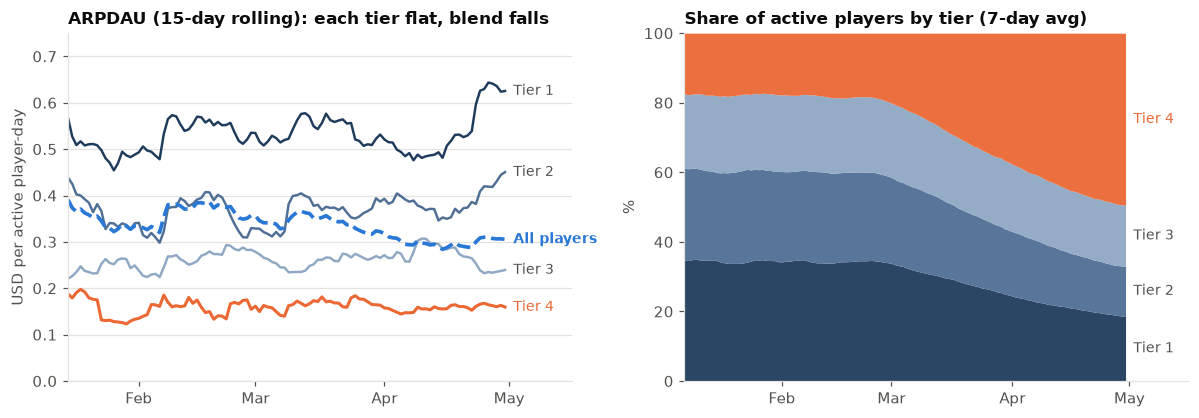

In [9]:
dau_tier = daily_tier.pivot(index="dt", columns="tier", values="dau")
share = dau_tier.div(dau_tier.sum(axis=1), axis=0).rolling(7).mean()
arp = (daily_tier.pivot(index="dt", columns="tier", values="revenue").rolling(15).sum()
       / dau_tier.rolling(15).sum())
blend = (daily_tier.groupby("dt").revenue.sum().rolling(15).sum()
         / daily_tier.groupby("dt").dau.sum().rolling(15).sum())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
ax = axes[0]
for k in (1, 2, 3, 4):
    ax.plot(arp.index, arp[k], color=ORANGE if k == 4 else GREYS[k - 1], lw=2 if k == 4 else 1.6)
    ax.text(arp.index[-1] + pd.Timedelta(days=2), arp[k].iloc[-1], f"Tier {k}", va="center",
            color=ORANGE if k == 4 else INK_2, fontsize=9)
ax.plot(blend.index, blend, color=BLUE, lw=2.4, ls="--")
ax.text(blend.index[-1] + pd.Timedelta(days=2), blend.iloc[-1], "All players", va="center", color=BLUE,
        fontsize=9, fontweight="bold")
ax.set_ylim(0, 0.75)
ax.set_title("ARPDAU (15-day rolling): each tier flat, blend falls")
ax.set_ylabel("USD per active player-day")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(arp.index[14], arp.index[-1] + pd.Timedelta(days=16))

ax = axes[1]
bottom = np.zeros(len(share))
for k in (1, 2, 3, 4):
    vals = share[k].fillna(0).to_numpy() * 100
    ax.fill_between(share.index, bottom, bottom + vals, color=ORANGE if k == 4 else GREYS[k - 1],
                    lw=0, alpha=0.95)
    mid = bottom[-1] + vals[-1] / 2
    ax.text(share.index[-1] + pd.Timedelta(days=2), mid, f"Tier {k}", va="center",
            color=ORANGE if k == 4 else INK_2, fontsize=9)
    bottom = bottom + vals
ax.set_ylim(0, 100)
ax.set_title("Share of active players by tier (7-day avg)")
ax.set_ylabel("%")
ax.grid(False)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(share.index[6], share.index[-1] + pd.Timedelta(days=16))
fig.tight_layout()
save(fig, "p2_mix_shift")
plt.show()

In [10]:
value = run_query("""
    SELECT p.country_tier AS tier,
           SUM(p.install_date <= '2026-03-31') AS installs_30d_obs,
           ROUND(SUM(CASE WHEN p.install_date <= '2026-03-31'
                    THEN COALESCE(r.rev30, 0) END) / SUM(p.install_date <= '2026-03-31'), 3) AS rev_per_install_30d,
           SUM(p.install_date <= '2026-02-28') AS installs_60d_obs,
           ROUND(SUM(CASE WHEN p.install_date <= '2026-02-28'
                    THEN COALESCE(r.rev60, 0) END) / SUM(p.install_date <= '2026-02-28'), 3) AS rev_per_install_60d,
           ROUND(SUM(CASE WHEN p.install_date <= '2026-02-28'
                    THEN COALESCE(r.rev30, 0) END) / SUM(p.install_date <= '2026-02-28'), 3) AS same_installs_30d
    FROM player_profile p
    LEFT JOIN (
        SELECT pc.device_id,
               SUM(CASE WHEN pc.event_dt < pp.install_date + INTERVAL 30 DAY THEN pc.usd_amount ELSE 0 END) AS rev30,
               SUM(CASE WHEN pc.event_dt < pp.install_date + INTERVAL 60 DAY THEN pc.usd_amount ELSE 0 END) AS rev60
        FROM purchase_clean pc JOIN player_profile pp USING (device_id)
        WHERE pc.usd_amount > 0
        GROUP BY pc.device_id
    ) r USING (device_id)
    WHERE p.install_date BETWEEN '2026-01-01' AND '2026-03-31'
    GROUP BY p.country_tier
    ORDER BY tier
""")
value["growth_30_to_60d"] = (value.rev_per_install_60d / value.same_installs_30d).round(2)
display(value)

,tier,installs_30d_obs,rev_per_install_30d,installs_60d_obs,rev_per_install_60d,same_installs_30d,growth_30_to_60d
0,1,9775.0,3.530,6446.0,5.542,3.541,1.57
1,2,7349.0,2.290,4806.0,3.693,2.271,1.63
2,3,7360.0,1.748,4189.0,2.505,1.627,1.54
3,4,13005.0,1.098,3839.0,1.630,1.051,1.55


In [11]:
# Rewarded-ad engagement by tier (ad revenue itself is not in the extract)
display(run_query("""
    SELECT p.country_tier AS tier,
           ROUND(SUM(COALESCE(a.completed, 0)) / SUM(d.active_days), 3) AS completed_ads_per_active_day
    FROM player_profile p
    JOIN (SELECT device_id, COUNT(*) AS active_days FROM player_day GROUP BY device_id) d USING (device_id)
    LEFT JOIN (SELECT device_id, COUNT(*) AS completed FROM ad_view_local
               WHERE status = 'completed' GROUP BY device_id) a USING (device_id)
    GROUP BY p.country_tier ORDER BY tier
"""))

,tier,completed_ads_per_active_day
0,1,0.568
1,2,0.667
2,3,0.864
3,4,1.014


## Final Interpretation

Overall ARPDAU fell from **$0.354 to $0.296 (-16.5%)**, while revenue per day increased from **$973 to $2,788 (2.87×)**. The two windows had the same number of sale days, so the promotion calendar does not explain the change.

The decline is primarily a **player-mix effect**. Tier 4 increased from **17.7% to 46.0% of active player-days**, while its ARPDAU remained around **$0.155**. The symmetric decomposition gives **−$0.081** from mix versus **+$0.023** from within-tier changes. The tier × tenure analysis gives the same result. Player-level bootstrap confirms the mix effect is consistently negative, while the within-tier effect is not distinguishable from zero.

The mix shift coincides with the rapid growth of **paid_video acquisition**, concentrated in Tier 4. Tier 4 generated about **$1.10 of observed 30-day IAP revenue per install and $1.63 by day 60**. These are value benchmarks, not profitability thresholds.

**Action:** Do not optimize blended ARPDAU alone. Evaluate acquisition using **channel × tier CPI, IAP revenue, ad revenue and longer-horizon value**. The current data are insufficient to determine whether additional Tier 4 acquisition is economically attractive. Any change to acquisition or promotion cadence should be validated with a controlled experiment rather than inferred from this observational analysis.

In [12]:
close()